In [169]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [171]:
df=pd.read_csv("Crop_recommendation.csv")

In [173]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,NaN,NaN,NaN,NaN,NaN
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,NaN,NaN,NaN,NaN,NaN
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,NaN,NaN,NaN,NaN,NaN
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,NaN,NaN,NaN,NaN,NaN
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,NaN,NaN,NaN,NaN,NaN


In [175]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1697 entries, 0 to 1696
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            1697 non-null   int64  
 1   P            1697 non-null   int64  
 2   K            1697 non-null   int64  
 3   temperature  1697 non-null   float64
 4   humidity     1697 non-null   float64
 5   ph           1697 non-null   float64
 6   rainfall     1697 non-null   float64
 7   label        1697 non-null   str    
 8   Unnamed: 8   0 non-null      float64
 9   Unnamed: 9   0 non-null      float64
 10  Unnamed: 10  8 non-null      str    
 11  Unnamed: 11  8 non-null      str    
 12  Unnamed: 12  8 non-null      str    
dtypes: float64(6), int64(3), str(4)
memory usage: 183.5 KB


In [179]:
df.isnull().sum()

N                 0
P                 0
K                 0
temperature       0
humidity          0
ph                0
rainfall          0
label             0
Unnamed: 8     1697
Unnamed: 9     1697
Unnamed: 10    1689
Unnamed: 11    1689
Unnamed: 12    1689
dtype: int64

In [181]:
df.columns


Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label',
       'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11',
       'Unnamed: 12'],
      dtype='str')

In [183]:
df=df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']]

In [185]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [23]:
df.shape

(1697, 8)

In [25]:
x=df.drop('label',axis=1)
y=df['label']

In [67]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

## Logistic Regression

In [70]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [72]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()

In [74]:
lr.fit(x_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [76]:
y_pred=lr.predict(x_test_scaled)

In [217]:
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix
cr=classification_report(y_test,y_pred)
a1=accuracy_score(y_test,y_pred)*100
cf=confusion_matrix(y_test,y_pred)
print(f"The accuracy is:{a1}")
print(cr)
print(cf)

The accuracy is:100.0
              precision    recall  f1-score   support

   Soyabeans       1.00      1.00      1.00        25
       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        25
       beans       1.00      1.00      1.00        31
      coffee       1.00      1.00      1.00        18
      cotton       1.00      1.00      1.00        23
     cowpeas       1.00      1.00      1.00        22
      grapes       1.00      1.00      1.00        22
  groundnuts       1.00      1.00      1.00        25
       maize       1.00      1.00      1.00        22
       mango       1.00      1.00      1.00        22
      orange       1.00      1.00      1.00        16
        peas       1.00      1.00      1.00        25
        rice       1.00      1.00      1.00        23
  watermelon       1.00      1.00      1.00        18

    accuracy                           1.00       340
   macro avg       1.00      1.00      1.00       340
weig

## Support Vector Machine

In [95]:
from sklearn.svm import SVC

In [97]:
svc=SVC()

In [103]:
svc.fit(x_train_scaled,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [105]:
y_pred=svc.predict(x_test_scaled)

In [107]:
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix
cr=classification_report(y_test,y_pred)
acc=accuracy_score(y_test,y_pred)
a2=confusion_matrix(y_test,y_pred)
print(f"The accuracy is:{acc*100}")
print(cr)
print(cf)

The accuracy is:99.41176470588235
              precision    recall  f1-score   support

   Soyabeans       1.00      1.00      1.00        25
       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        25
       beans       0.97      1.00      0.98        31
      coffee       1.00      1.00      1.00        18
      cotton       0.96      1.00      0.98        23
     cowpeas       1.00      1.00      1.00        22
      grapes       1.00      1.00      1.00        22
  groundnuts       1.00      1.00      1.00        25
       maize       1.00      0.95      0.98        22
       mango       1.00      1.00      1.00        22
      orange       1.00      1.00      1.00        16
        peas       1.00      0.96      0.98        25
        rice       1.00      1.00      1.00        23
  watermelon       1.00      1.00      1.00        18

    accuracy                           0.99       340
   macro avg       1.00      0.99      0.99   

## Descision Tree 

In [110]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()

In [112]:
dt.fit(x_train_scaled,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [114]:
y_pred=dt.predict(x_test_scaled)

In [116]:
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix
cr=classification_report(y_test,y_pred)
acc=accuracy_score(y_test,y_pred)
a3=confusion_matrix(y_test,y_pred)
print(f"The accuracy is:{acc*100}")
print(cr)
print(cf)

The accuracy is:100.0
              precision    recall  f1-score   support

   Soyabeans       1.00      1.00      1.00        25
       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        25
       beans       1.00      1.00      1.00        31
      coffee       1.00      1.00      1.00        18
      cotton       1.00      1.00      1.00        23
     cowpeas       1.00      1.00      1.00        22
      grapes       1.00      1.00      1.00        22
  groundnuts       1.00      1.00      1.00        25
       maize       1.00      1.00      1.00        22
       mango       1.00      1.00      1.00        22
      orange       1.00      1.00      1.00        16
        peas       1.00      1.00      1.00        25
        rice       1.00      1.00      1.00        23
  watermelon       1.00      1.00      1.00        18

    accuracy                           1.00       340
   macro avg       1.00      1.00      1.00       340
weig

In [129]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

scores = cross_val_score(
    dt,
    x,
    y,
    cv=5,
    scoring='accuracy'
)

print("CV Scores:", scores)
print("Mean Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

CV Scores: [1.         0.99411765 1.         0.99410029 1.        ]
Mean Accuracy: 0.9976435884088148
Standard Deviation: 0.002886008227648222


## random Forest

In [119]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()

In [121]:
rf.fit(x_train_scaled,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [123]:
y_pred=dt.predict(x_test_scaled)

In [125]:
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix
cr=classification_report(y_test,y_pred)
acc=accuracy_score(y_test,y_pred)
a4=confusion_matrix(y_test,y_pred)
print(f"The accuracy is:{acc*100}")
print(cr)
print(cf)

The accuracy is:100.0
              precision    recall  f1-score   support

   Soyabeans       1.00      1.00      1.00        25
       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        25
       beans       1.00      1.00      1.00        31
      coffee       1.00      1.00      1.00        18
      cotton       1.00      1.00      1.00        23
     cowpeas       1.00      1.00      1.00        22
      grapes       1.00      1.00      1.00        22
  groundnuts       1.00      1.00      1.00        25
       maize       1.00      1.00      1.00        22
       mango       1.00      1.00      1.00        22
      orange       1.00      1.00      1.00        16
        peas       1.00      1.00      1.00        25
        rice       1.00      1.00      1.00        23
  watermelon       1.00      1.00      1.00        18

    accuracy                           1.00       340
   macro avg       1.00      1.00      1.00       340
weig

In [131]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

scores = cross_val_score(
    rf,
    x,
    y,
    cv=5,
    scoring='accuracy'
)

print("CV Scores:", scores)
print("Mean Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

CV Scores: [1.         0.99705882 1.         1.         1.        ]
Mean Accuracy: 0.9994117647058823
Standard Deviation: 0.00117647058823529


## Hyperameter Tuning

In [199]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(x_train_scaled, y_train)
a3=grid.best_score_*100
print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", a3)


Best Parameters: {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Accuracy: 99.11547644888212


In [209]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    random_state=42
)

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(x_train_scaled, y_train)

print("Best Parameters:")
print(rf_grid.best_params_)
a4=rf_grid.best_score_*100
print("\nBest CV Accuracy:")
print(a4)


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}

Best CV Accuracy:
99.92647058823529


In [203]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

svc = SVC()

svc_params = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear', 'poly']
}

svc_grid = GridSearchCV(
    estimator=svc,
    param_grid=svc_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

svc_grid.fit(x_train_scaled, y_train)

print("Best Parameters:")
print(svc_grid.best_params_)
a2=svc_grid.best_score_*100
print("\nBest CV Accuracy:")
print(a2)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best Parameters:
{'C': 10, 'gamma': 1, 'kernel': 'rbf'}

Best CV Accuracy:
99.92647058823529


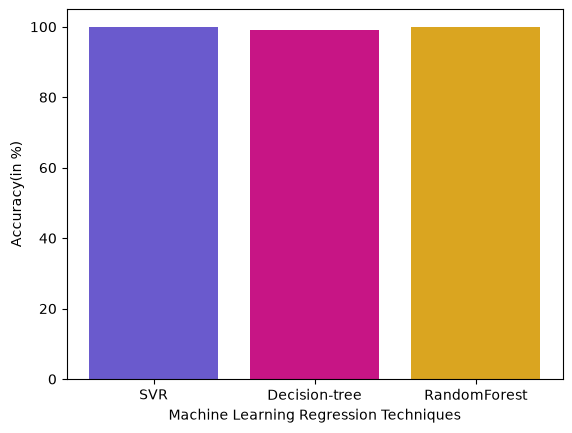

In [225]:
# Mean Accuracy
import numpy as np
import matplotlib.pyplot as plt
 
# create a dataset
Algorithms = ['SVR', 'Decision-tree', 'RandomForest']
Accuracy = [a2,a3,a4]

x_pos = np.arange(len(Accuracy))

# Create bars with different colors
plt.bar(x_pos, Accuracy, color=['#6A5ACD','#C71585','#DAA520'])
# Create names on the x-axis
plt.xticks(x_pos, Algorithms)
plt.ylabel('Accuracy(in %)')
plt.xlabel('Machine Learning Regression Techniques')

# Show graph
plt.show()

In [239]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

model.fit(X_xtrain_scaled, y_train)

joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

NameError: name 'X_train_scaled' is not defined